### Bài 3: Xây dựng kiến trúc Encoder trong đó Encoder gồm 5 lớp BiLSTM với hidden size là 256 cho bài toán nhận diện thực thể (Name Entity Recognition). Huấn luyện mô hình trên bộ dữ liệu PhoNER và đánh giá độ hiệu quả của mô hình sử dụng độ đo F1.

In [2]:
import os

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
!pip install -q seqeval

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [4]:
import numpy as np

## 1. Đọc dữ liệu

In [5]:
def load_conll(file_path):
    """
    Đọc file .conll và trả về list các câu và list các nhãn tương ứng.
    """
    sentences = []
    tags = []

    current_sent = []
    current_tags = []

    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()

            # Gặp dòng trắng (hoặc hết file) nghĩa là kết thúc 1 câu
            if not line:
                if len(current_sent) > 0:
                    sentences.append(current_sent)
                    tags.append(current_tags)
                    current_sent = []
                    current_tags = []
            else:
                # Tách từ và nhãn (cách nhau bởi space)
                parts = line.split()
                # "Bác_sĩ O" -> len=2

                if len(parts) >= 2:
                    word = parts[0]
                    tag = parts[-1] # Lấy phần tử cuối cùng làm tag

                    current_sent.append(word)
                    current_tags.append(tag)

    # Thêm câu cuối cùng nếu file không kết thúc bằng dòng trắng
    if len(current_sent) > 0:
        sentences.append(current_sent)
        tags.append(current_tags)

    return sentences, tags

In [6]:
# Đường dẫn thư mục dữ liệu trên Drive
data_dir = "/content/drive/MyDrive/MonHocTrenTruong/DS201/Lab-thuc-hanh/Lab-3/Bai3_data"

# Đường dẫn đến các file conll
train_file = os.path.join(data_dir, "train_word.conll")
dev_file   = os.path.join(data_dir, "dev_word.conll")
test_file  = os.path.join(data_dir, "test_word.conll")

# Load dữ liệu
train_sents, train_tags = load_conll(train_file)
dev_sents, dev_tags     = load_conll(dev_file)
test_sents, test_tags    = load_conll(test_file)

print(f"Số lượng câu train: {len(train_sents)}")
print(f"Câu train đầu tiên: {train_sents[0]}")
print(f"Số lượng unique nhãn train: {len(set(tag for tags in train_tags for tag in tags))}")

Số lượng câu train: 5027
Câu train đầu tiên: ['Đồng_thời', ',', 'bệnh_viện', 'tiếp_tục', 'thực_hiện', 'các', 'biện_pháp', 'phòng_chống', 'dịch_bệnh', 'COVID', '-', '19', 'theo', 'hướng_dẫn', 'của', 'Bộ', 'Y_tế', '.']
Số lượng unique nhãn train: 20


## 2. Mã hóa dữ liệu (Tokenization & Encoding)

### a. Chọn các siêu tham số - Dựa trên phân tích EDA

In [7]:
MAX_LEN = 126
NUM_CLASSES = 21

### b. Xây dựng các hàm xử lý thủ công - Tạo tập từ điển + encoding

In [8]:
def create_vocab(sentences):
    """Tạo bộ từ điển từ danh sách các câu (list of lists)"""
    vocab_set = set()
    for sent in sentences:
        vocab_set.update(sent)
    return sorted(list(vocab_set))

def create_mappings(vocab_list, all_tags_list):
    """Tạo mapping từ chữ/nhãn sang số"""
    # word2idx: 0 cho Padding, 1 cho Unknown
    word2idx = {'<PAD>': 0, '<UNK>': 1}
    for idx, word in enumerate(vocab_list, start=2):
        word2idx[word] = idx

    # tag2idx: Chỉ map các nhãn thực tế
    unique_tags = sorted(list(set(tag for tags in all_tags_list for tag in tags)))
    tag2idx = {tag: idx for idx, tag in enumerate(unique_tags)}

    return word2idx, tag2idx

In [9]:
vocab_list = create_vocab(train_sents)
word2idx, tag2idx = create_mappings(vocab_list, train_tags)

print(f"Kích thước tập từ vựng (Vocab size): {len(word2idx)}")
print(f"Danh sách nhãn và ID tương ứng:\n{tag2idx}")

Kích thước tập từ vựng (Vocab size): 5243
Danh sách nhãn và ID tương ứng:
{'B-AGE': 0, 'B-DATE': 1, 'B-GENDER': 2, 'B-JOB': 3, 'B-LOCATION': 4, 'B-NAME': 5, 'B-ORGANIZATION': 6, 'B-PATIENT_ID': 7, 'B-SYMPTOM_AND_DISEASE': 8, 'B-TRANSPORTATION': 9, 'I-AGE': 10, 'I-DATE': 11, 'I-JOB': 12, 'I-LOCATION': 13, 'I-NAME': 14, 'I-ORGANIZATION': 15, 'I-PATIENT_ID': 16, 'I-SYMPTOM_AND_DISEASE': 17, 'I-TRANSPORTATION': 18, 'O': 19}


In [10]:
def encode_and_pad(data_sents, data_tags, word2idx, tag2idx, max_len):
    """Chuyển câu và nhãn thành dãy số và padding"""
    encoded_sents = []
    encoded_tags = []

    for sent, tags in zip(data_sents, data_tags):
        # 1. Encode Sentence
        sent_seq = [word2idx.get(word, word2idx['<UNK>']) for word in sent]

        # 2. Encode Tags
        tag_seq = [tag2idx.get(tag) for tag in tags]

        # 3. Padding/Truncating
        if len(sent_seq) < max_len:
            # Padding: Thêm 0 cho câu, thêm -100 cho nhãn
            sent_seq = sent_seq + [word2idx['<PAD>']] * (max_len - len(sent_seq))
            tag_seq = tag_seq + [-100] * (max_len - len(tag_seq))
        else:
            # Truncating: Cắt bớt nếu dài quá max_len
            sent_seq = sent_seq[:max_len]
            tag_seq = tag_seq[:max_len]

        encoded_sents.append(sent_seq)
        encoded_tags.append(tag_seq)

    return np.array(encoded_sents), np.array(encoded_tags)

In [11]:
# Thực thi mã hóa cho cả 3 tập
train_ids, train_tag_ids = encode_and_pad(train_sents, train_tags, word2idx, tag2idx, MAX_LEN)
dev_ids, dev_tag_ids = encode_and_pad(dev_sents, dev_tags, word2idx, tag2idx, MAX_LEN)
test_ids, test_tag_ids = encode_and_pad(test_sents, test_tags, word2idx, tag2idx, MAX_LEN)

print(f"Shape tập train: {train_ids.shape}")
print(f"Shape nhãn train: {train_tag_ids.shape}")
print("Câu đầu tiên:", train_ids[0][:20])
print("Câu đầu tiên:", train_tag_ids[0][:20])

Shape tập train: (5027, 126)
Shape nhãn train: (5027, 126)
Câu đầu tiên: [5019   10 2783 4457 4421 2999 2687 4037 3186 1283   11  265 4296 3383
 3104 1267 2644   12    0    0]
Câu đầu tiên: [  19   19   19   19   19   19   19   19   19   19   19   19   19   19
   19    6   15   19 -100 -100]


> Câu thứ 1 trong bộ train:
>
>Đồng_thời, bệnh_viện tiếp_tục thực_hiện các biện_pháp phòng_chống dịch_bệnh COVID-19 theo hướng_dẫn của Bộ Y_tế.

- 19 là đại diện cho nhãn `O - Outside`
- `-100 là padding 0` do trong PyTorch, hàm mất mát nn.CrossEntropyLoss có một tham số mặc định là ignore_index=-100, khi tính loss thì sẽ bỏ qua các vị trí có nhãn là -100.

## 3. Tạo Dataset/DataLoader và xây dựng Model.

### a. Tạo Dataset và DataLoader

In [12]:
print(train_ids.dtype)
print(type(train_ids))

int64
<class 'numpy.ndarray'>


In [13]:
import torch
from torch.utils.data import TensorDataset, DataLoader

# Chuyển đổi Numpy sang Tensor
# Lưu ý: Input là LongTensor (số nguyên) vì nó là index
train_data = TensorDataset(torch.from_numpy(train_ids), torch.from_numpy(train_tag_ids))
dev_data = TensorDataset(torch.from_numpy(dev_ids), torch.from_numpy(dev_tag_ids))
test_data = TensorDataset(torch.from_numpy(test_ids), torch.from_numpy(test_tag_ids))

# Thiết lập Batch Size
BATCH_SIZE = 32

# Tạo DataLoader
# shuffle=True cho tập train để mô hình học tốt hơn
train_loader = DataLoader(train_data, shuffle=True, batch_size=BATCH_SIZE)
dev_loader = DataLoader(dev_data, shuffle=False, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_data, shuffle=False, batch_size=BATCH_SIZE)

print(f"Số lượng batch trong tập train: {len(train_loader)}")

Số lượng batch trong tập train: 158


### b. Xây dựng Kiến trúc BiLSTM

In [14]:
import torch.nn as nn

class BiLSTM_NER(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, n_layers, n_classes, dropout=0.5):
        super(BiLSTM_NER, self).__init__()

        # Embedding Layer
        # padding_idx=0: Vector tại index 0 sẽ luôn là vector 0, không được train
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        # BiLSTM Layer
        self.lstm = nn.LSTM(input_size=embedding_dim,
                            hidden_size=hidden_size,
                            num_layers=n_layers,
                            bidirectional=True, # Bi-directional
                            batch_first=True,   # Input dạng [batch, seq_len, feature]
                            dropout=dropout)

        # Fully Connected Layer (Classifier)
        # Input của FC là hidden_size * 2 (do 2 chiều xuôi/ngược)
        self.fc = nn.Linear(hidden_size * 2, n_classes) # Không softmax, vì dùng CrossEntropyLoss

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # x shape: [batch_size, seq_len]

        # Pass qua Embedding
        embedded = self.embedding(x)
        embedded = self.dropout(embedded) # sinh ra tensor [batch, seq_len, embedding_dim]

        # Pass qua LSTM
        # outputs shape: [batch_size, seq_len, hidden_size * 2]
        outputs, hidden = self.lstm(embedded)
        outputs = self.dropout(outputs)

        # Pass qua FC để ra xác suất cho từng class
        # predictions shape: [batch_size, seq_len, n_classes]
        predictions = self.fc(outputs)

        return predictions

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = BiLSTM_NER(vocab_size=len(word2idx),
                   embedding_dim=100,  # Thường chọn 100 hoặc 300
                   hidden_size=256,    # Theo đề bài
                   n_layers=5,         # Theo đề bài
                   n_classes=NUM_CLASSES,
                   dropout=0.3).to(device)

print(model)

BiLSTM_NER(
  (embedding): Embedding(5243, 100, padding_idx=0)
  (lstm): LSTM(100, 256, num_layers=5, batch_first=True, dropout=0.3, bidirectional=True)
  (fc): Linear(in_features=512, out_features=21, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)


In [15]:
import torch.optim as optim

# Định nghĩa Loss Function
# ignore_index=-100: Bỏ qua các nhãn padding khi tính loss
criterion = nn.CrossEntropyLoss(ignore_index=-100)

# Định nghĩa Optimizer
optimizer = optim.Adam(model.parameters(), lr=0.0001)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Tổng số tham số cần huấn luyện: {count_parameters(model):,}")

Tổng số tham số cần huấn luyện: 7,576,097


### c. Training thử nghiệm

In [16]:
from tqdm import tqdm

def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train() # Chuyển model sang chế độ train (bật dropout)
    epoch_loss = 0

    for batch_sents, batch_tags in tqdm(dataloader, desc="Training"):
        # Chuyển data lên GPU
        batch_sents = batch_sents.to(device)
        batch_tags = batch_tags.to(device)

        # 1. Xóa gradient cũ
        optimizer.zero_grad()

        # 2. Forward pass
        # predictions shape: [batch_size, seq_len, n_classes]
        predictions = model(batch_sents)

        # 3. Tính Loss
        # PyTorch CrossEntropy yêu cầu:
        # - Input: [Batch_size * Seq_len, Num_classes] (2D)
        # - Target: [Batch_size * Seq_len] (1D)
        predictions = predictions.view(-1, predictions.shape[-1])
        batch_tags = batch_tags.view(-1)

        loss = criterion(predictions, batch_tags)

        # 4. Backward pass
        loss.backward()

        # 5. Update weights
        optimizer.step()

        epoch_loss += loss.item()

    return epoch_loss / len(dataloader)

# Chạy thử 1 epoch để xem code có lỗi không trước khi train full
print("Đang chạy thử 1 epoch...")
train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
print(f"Train Loss: {train_loss:.4f}")

Đang chạy thử 1 epoch...


Training: 100%|██████████| 158/158 [00:11<00:00, 14.28it/s]

Train Loss: 1.2872


Hàm đánh giá + lưu lịch sử training

In [21]:
from seqeval.metrics import classification_report, f1_score

# 1. Tạo dict ngược để dịch số về nhãn (0 -> B-ORG)
idx2tag = {v: k for k, v in tag2idx.items()}

def evaluate(model, dataloader, criterion, device):
    model.eval() # Quan trọng: Tắt dropout
    epoch_loss = 0
    y_true = []
    y_pred = []

    with torch.no_grad(): # Tắt tính gradient để tiết kiệm RAM
        for batch_sents, batch_tags in dataloader:
            batch_sents = batch_sents.to(device)
            batch_tags = batch_tags.to(device)

            # Forward pass
            predictions = model(batch_sents)

            # --- TÍNH VAL LOSS ---
            # Reshape giống lúc train
            predictions_flat = predictions.view(-1, predictions.shape[-1])
            batch_tags_flat = batch_tags.view(-1)
            loss = criterion(predictions_flat, batch_tags_flat)
            epoch_loss += loss.item()

            # Lấy nhãn có xác suất cao nhất (argmax)
            # predictions shape: [batch, seq_len, n_classes] -> [batch, seq_len]
            preds = torch.argmax(predictions, dim=2)

            # Chuyển Tensor về List python để xử lý
            preds = preds.detach().cpu().numpy()
            targets = batch_tags.detach().cpu().numpy()

            # Lặp qua từng câu trong batch
            for p_sent, t_sent in zip(preds, targets):
                sent_true = []
                sent_pred = []

                # Lặp qua từng từ trong câu
                for p, t in zip(p_sent, t_sent):
                    # Quan trọng: Chỉ lấy những nhãn KHÔNG phải là padding (-100)
                    if t != -100:
                        sent_true.append(idx2tag[t])
                        sent_pred.append(idx2tag[p])

                # Lưu lại kết quả của câu đó
                y_true.append(sent_true)
                y_pred.append(sent_pred)

    return epoch_loss / len(dataloader), y_true, y_pred

### d. Training 40 epochs

In [22]:
import time
import torch
from seqeval.metrics import f1_score

N_EPOCHS = 40

# Biến lưu F1 tốt nhất để checkpoint
best_valid_f1 = float('-inf')
history = {'train_loss': [], 'valid_loss': [], 'valid_f1': []}

print(f"Bắt đầu huấn luyện {N_EPOCHS} epochs trên thiết bị: {device}")
print("-" * 80)

for epoch in range(N_EPOCHS):
    start_time = time.time()

    # 1. Huấn luyện (Train)
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)

    # 2. Đánh giá trên tập Dev (Validation)
    # Lưu ý: Hàm evaluate đã định nghĩa ở bước trước, trả về list các nhãn thực và dự đoán
    val_loss, true_labels, pred_labels = evaluate(model, dev_loader, criterion, device)
    valid_f1 = f1_score(true_labels, pred_labels)

    # 3. Lưu lịch sử
    history['train_loss'].append(train_loss)
    history['valid_f1'].append(valid_f1)
    history['valid_loss'].append(val_loss)
    # history['train_f1'].append(train_f1)

    # 4. Lưu model tốt nhất (Checkpoint)
    save_msg = ""
    if valid_f1 > best_valid_f1:
        best_valid_f1 = valid_f1
        torch.save(model.state_dict(), 'best_model.pth')
        save_msg = "--> Đã lưu model tốt nhất!"

    # In kết quả epoch
    end_time = time.time()
    mins, secs = divmod(end_time - start_time, 60)

    print(f'Epoch: {epoch+1:02} | Time: {int(mins)}m {int(secs)}s | '
          f'Train Loss: {train_loss:.4f} | Val F1: {valid_f1:.4f} {save_msg}')

Bắt đầu huấn luyện 40 epochs trên thiết bị: cuda
--------------------------------------------------------------------------------


Training: 100%|██████████| 158/158 [00:10<00:00, 14.75it/s]


Epoch: 01 | Time: 0m 12s | Train Loss: 0.7263 | Val F1: 0.1230 --> Đã lưu model tốt nhất!


Training: 100%|██████████| 158/158 [00:10<00:00, 14.72it/s]


Epoch: 02 | Time: 0m 12s | Train Loss: 0.5765 | Val F1: 0.2975 --> Đã lưu model tốt nhất!


...

Epoch: 38 | Time: 0m 13s | Train Loss: 0.0616 | Val F1: 0.8688 --> Đã lưu model tốt nhất!


Training: 100%|██████████| 158/158 [00:11<00:00, 13.79it/s]


Epoch: 39 | Time: 0m 13s | Train Loss: 0.0594 | Val F1: 0.8713 --> Đã lưu model tốt nhất!


Training: 100%|██████████| 158/158 [00:12<00:00, 13.12it/s]


Epoch: 40 | Time: 0m 13s | Train Loss: 0.0596 | Val F1: 0.8743 --> Đã lưu model tốt nhất!


### e. Đánh giá

>Ta sẽ dùng thư viện `seqeval` để đánh giá theo chuẩn bài toán NER. Đây cũng là lý do tại sao classification report ở dưới chỉ hiện 10 nhãn, chứ không phải 21 nhãn. Chúng ta sẽ đánh giá ở cấp độ thực thể, chỉ đúng nếu khớp đúng 100% thực thể.

>Ví dụ: Bác_Sĩ cho biết ca lây_nhiễm 12 tại trường_học Nguyễn_Văn_A thì chỉ khớp nếu Nguyễn - B-LOC | Văn - I-LOC | A - I-LOC. Nếu một thành phần sai thì cũng tính là sai.

In [27]:
from seqeval.metrics import classification_report

# Load lại trọng số của model tốt nhất (Best Checkpoint)
model.load_state_dict(torch.load('best_model.pth', map_location=device))

# Chạy đánh giá trên tập Test
_, test_true_labels, test_pred_labels = evaluate(model, test_loader, criterion, device)

# In báo cáo chi tiết
print("\n" + "="*30)
print("KẾT QUẢ ĐÁNH GIÁ (TEST SET)")
print("="*30)
print(classification_report(test_true_labels, test_pred_labels, digits=4))


KẾT QUẢ ĐÁNH GIÁ (TEST SET)
                     precision    recall  f1-score   support

                AGE     0.9165    0.9449    0.9305       581
               DATE     0.9417    0.9479    0.9448      1652
             GENDER     0.9359    0.8872    0.9109       461
                JOB     0.4382    0.2254    0.2977       173
           LOCATION     0.8525    0.8803    0.8662      4437
               NAME     0.6963    0.2956    0.4150       318
       ORGANIZATION     0.7814    0.7419    0.7611       771
         PATIENT_ID     0.8848    0.9555    0.9188      2002
SYMPTOM_AND_DISEASE     0.8093    0.7694    0.7888      1136
     TRANSPORTATION     0.8516    0.8031    0.8267       193

          micro avg     0.8642    0.8595    0.8618     11724
          macro avg     0.8108    0.7451    0.7661     11724
       weighted avg     0.8578    0.8595    0.8555     11724



Macro F1 đạt 0.766 - khá tốt, tuy nhiên 1 số lớp có kết quả khá kém (JOB và NAME), ta đặt ra nghi vấn mất cân bằng mẫu cho 2 loại thực thể này. Trong code EDA cũng đã chỉ ra, hầu hết các thực thể này, khả năng cao là do nó chưa từng gặp các từ vựng đó trong tập train.

In [31]:
from collections import Counter

all_tags = [tag for tags in train_tags for tag in tags]
tag_counts = Counter(all_tags)

print(f"{'Tag':<30} {'Count'}")
print("-" * 40)
for tag, count in tag_counts.most_common():
    print(f"{tag:<30} {count}")

Tag                            Count
----------------------------------------
O                              104750
B-LOCATION                     5398
I-LOCATION                     5242
B-PATIENT_ID                   3240
B-DATE                         2549
I-ORGANIZATION                 2545
I-DATE                         2500
I-SYMPTOM_AND_DISEASE          1552
B-SYMPTOM_AND_DISEASE          1439
B-ORGANIZATION                 1137
B-AGE                          682
B-GENDER                       542
B-NAME                         349
B-TRANSPORTATION               226
B-JOB                          205
I-TRANSPORTATION               67
I-JOB                          62
I-NAME                         13
I-PATIENT_ID                   11
I-AGE                          2


Nhưng mà TRANSPORTATION cũng ít mà kết quả vẫn cao => nghi vấn giá trị unique ít => Bắt tốt

=> Ta sẽ đi kiểm tra độ đa dạng của các thực thể

In [33]:
import pandas as pd
from collections import defaultdict

def analyze_diversity(sentences, tags, target_list=['JOB', 'NAME', 'TRANSPORTATION']):
    # Lưu danh sách các từ vựng thu được cho mỗi nhãn
    entities = defaultdict(list)

    for sent, sent_tags in zip(sentences, tags):
        curr_words, curr_tag = [], None

        for word, tag in zip(sent, sent_tags):
            # Bắt đầu thực thể mới (B-)
            if tag.startswith('B-'):
                if curr_tag in target_list: entities[curr_tag].append(" ".join(curr_words))
                curr_words, curr_tag = [word], tag[2:] # Lấy tên nhãn bỏ tiền tố B-
            # Nối tiếp thực thể cũ (I-)
            elif tag.startswith('I-') and curr_tag == tag[2:]:
                curr_words.append(word)
            # Gặp O hoặc nhãn khác -> Kết thúc thực thể hiện tại
            else:
                if curr_tag in target_list: entities[curr_tag].append(" ".join(curr_words))
                curr_words, curr_tag = [], None

        # Xử lý thực thể nằm cuối câu
        if curr_tag in target_list: entities[curr_tag].append(" ".join(curr_words))

    # In bảng thống kê
    print(f"{'TAG':<15} | {'TOTAL':<6} | {'UNIQUE':<6} | {'RATIO':<6} | {'TOP 3 EXAMPLES'}")
    print("-" * 100)

    for tag in target_list:
        vals = entities[tag]
        total, unique = len(vals), len(set(vals))
        # Ratio = 1 nghĩa là mỗi từ chỉ xuất hiện đúng 1 lần (siêu đa dạng/khó học)
        # Ratio gần 0 nghĩa là lặp lại nhiều (dễ học)
        ratio = unique / total if total > 0 else 0

        # Lấy top 10 từ xuất hiện nhiều nhất
        top10 = pd.Series(vals).value_counts().head(10).index.tolist()
        print(f"{tag:<15} | {total:<6} | {unique:<6} | {ratio:<6.2f} | {top10}")

# --- GỌI HÀM ---
analyze_diversity(train_sents, train_tags)

TAG             | TOTAL  | UNIQUE | RATIO  | TOP 3 EXAMPLES
----------------------------------------------------------------------------------------------------
JOB             | 205    | 50     | 0.24   | ['phi_công', 'điều_dưỡng', 'du_học_sinh', 'lái_xe', 'doanh_nhân', 'tiếp_viên', 'công_nhân', 'nhân_viên y_tế', 'thầy_giáo', 'buôn_bán']
NAME            | 349    | 112    | 0.32   | ['T.', 'N.H.N.', 'Nhung', 'Nguyễn_Hồng_Nhung', 'H.', 'N.', 'C.', 'B', 'D.Đ.P.', 'A']
TRANSPORTATION  | 226    | 69     | 0.31   | ['VN54', 'VN0054', 'VN 0054', 'VN0062', 'SU 290', 'VN6', 'VN5062', 'VN50', 'VN0050', 'VN 54']


>Ta thấy giải thuyết mức độ đa dạng chưa phải là tất cả?

>Khi NAME có tỉ lệ đa dạng cao, nên kết quả thấp là hợp lý.

>Nhưng TRANSPORTATION cũng có tỉ lệ đang dạng cao, nhưng kết quả F1 vẫn cao (0.81)

>JOB đa dạng thấp nhất nhưng lại kết quả lại thấp nhất.

=> Câu trả lời khả thi nhất là các từ của NAME, TRANSPORTATION đều có quy luật hình thái rõ ràng (Viết tắt, Mã số), trong khi JOB token lại khá giống các từ bình thường khác trong câu.

=> Vấn đề không chỉ nằm ở số lượng từ vựng mà nằm ở đặc trưng hình thái và ngữ cảnh của câu nói.

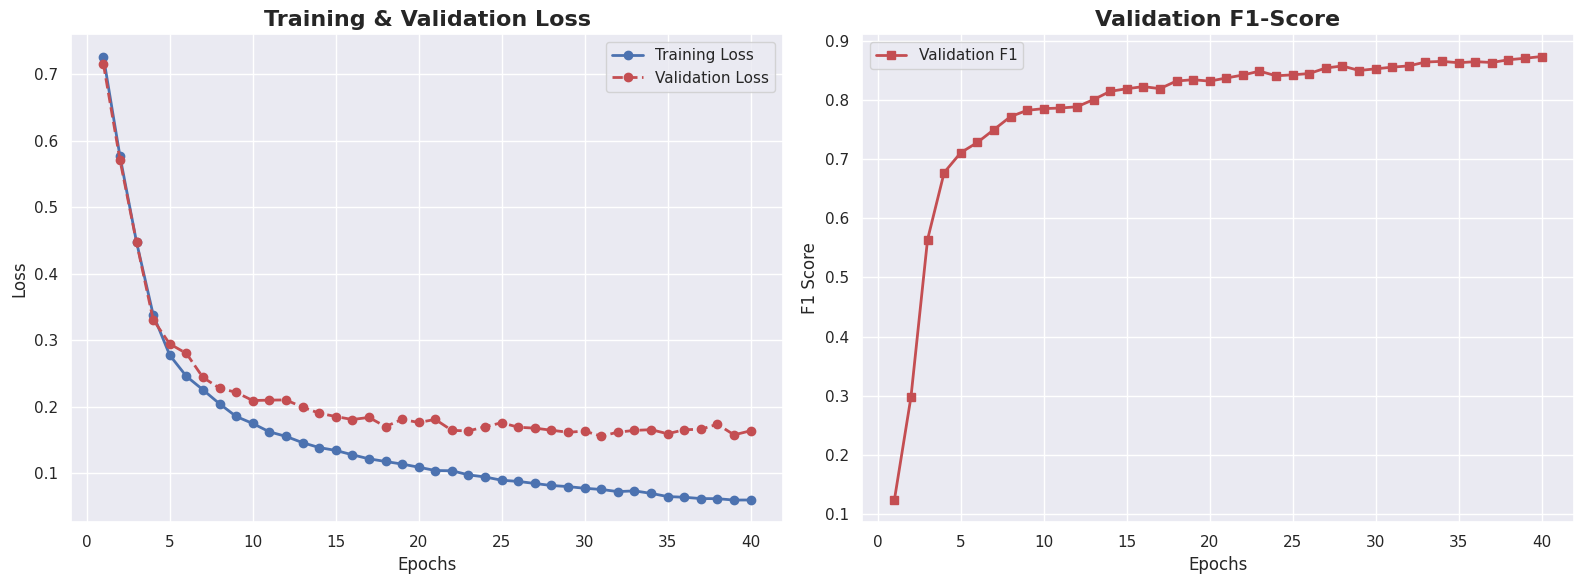

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sử dụng style seaborn
sns.set(style='darkgrid')

def plot_training_history(history):
    """
    history: dictionary chứa các key: 'train_loss', 'valid_loss', 'train_f1', 'valid_f1'
    """

    # Tạo khung hình vẽ gồm 2 biểu đồ con
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Lấy dữ liệu epochs
    epochs = range(1, len(history['train_loss']) + 1)

    # --- Biểu đồ 1: Loss (Train vs Valid) ---
    # Vẽ Train Loss
    ax1.plot(epochs, history['train_loss'], 'b-o', label='Training Loss', linewidth=2)
    # Vẽ Valid Loss (nếu có trong history)
    if 'valid_loss' in history:
        ax1.plot(epochs, history['valid_loss'], 'r--o', label='Validation Loss', linewidth=2)

    ax1.set_title('Training & Validation Loss', fontsize=16, fontweight='bold')
    ax1.set_xlabel('Epochs', fontsize=12)
    ax1.set_ylabel('Loss', fontsize=12)
    ax1.legend(loc='best')

    # --- Biểu đồ 2: F1-Score (Train vs Valid) ---
    # Vẽ Valid F1 (Quan trọng nhất)
    if 'valid_f1' in history:
        ax1_line = ax2.plot(epochs, history['valid_f1'], 'r-s', label='Validation F1', linewidth=2)

    # Vẽ Train F1 (để so sánh xem có học tủ không)
    if 'train_f1' in history:
        ax2.plot(epochs, history['train_f1'], 'b--s', label='Training F1', linewidth=2, alpha=0.6)

    ax2.set_title('Validation F1-Score', fontsize=16, fontweight='bold')
    ax2.set_xlabel('Epochs', fontsize=12)
    ax2.set_ylabel('F1 Score', fontsize=12)
    ax2.legend(loc='best')

    plt.tight_layout()
    plt.show()

# Gọi hàm (đảm bảo biến history của bạn đã lưu đủ các thông số trên)
plot_training_history(history)

Ta thấy loss giảm khá mượt, mặc dù có một chút dấu hiệu overfiting khi val los giảm rất ít khi so với training loss sau epoch 15